## Importing Libraries

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = '3'

import pandas as pd
import numpy as np
import prince
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, hamming_loss


## Generating Dataset

In [3]:
Questionaire = {
    'Q0': "For learning : I prefer learner’s engagement.",
    'Q1': "For learning : I prefer watching online video.",
    'Q2': "For learning : I prefer reading books.",
    'Q3': "For learning : I prefer reading online articles.",
    'Q4': "For learning : I prefer doing own research.",
    'Q5': "For learning : I prefer listening to experts.",
    'Q6': "For learning : I prefer online group discussion.",
    'Q7': "For learning : I prefer web-based interactive materials.",
    'Q8': "For learning : I prefer Q&A sessions.",
    'Q9': "For learning : I prefer group projects.",
    'Q10': "For learning : I prefer case studies.",
    'Q11': "For learning : I prefer problem-based learning.",
    'Q12': "For learning : I prefer examples and applications.",
    'Q13': "For learning : I prefer independent learning.",
    'Q14': "For learning : I prefer simulation.",
    'Q15': "My response to images and graphics for learning : I like learning by visualization, like use of pictures, videos, slides.",
    'Q16': "My response to images and graphics for learning : I like learning by using diagrams, graphs and charts.",
    'Q17': "My response to images and graphics for learning : I follow written directions better than oral directions.",
    'Q18': "My response to images and graphics for learning : I can better understand and follow directions using maps.",
    'Q19': "My response to images and graphics for learning : I like reading lists, bullet points and numbered paragraphs.",
    'Q20': "My response to images and graphics for learning : When learning from Internet, I like videos showing how to do.",
    'Q21': "My response for verbal presentations for learning : I can remember more by listening than reading.",
    'Q22':	"My response for verbal presentations for learning : I do better at academic subjects by listening to lectures.",
    'Q23': "My response for verbal presentations for learning : I like listen to a good lecture than read about the same material.",
    'Q24': "My response for verbal presentations for learning : I prefer listening a news on radio than reading it in a newspaper.",
    'Q25': "My response for physical approaches for learning : I like attending labs and practical session.",
    'Q26':	"My response for physical approaches for learning : I like to make visuals (concept maps, charts, graphs and models).",
    'Q27': "My response for physical approaches for learning : I like to participate in games for learning.",
    'Q28': "My response for physical approaches for learning : I prefer to learns by doing, and involving directly.",
    'Q29': "I think : I am satisfied with the way I am learning in my institution.",				
    'Q30':	"I think : the quality of education in my institution should be better.",
    'Q31':	"I think : there are better ways of learning other than the way I follow now."
}

LSQ = {'Q0':'K', 'Q1':'V', 'Q2':'R', 'Q3':'R','Q4':'K', 'Q5':'A', 'Q6':'K', 'Q7':'V', 'Q8':'K', 'Q9':'K', 'Q10':'K', 'Q11':'K', 'Q12': 'K', 'Q13':'K', 'Q14':'V',
       'Q15':'V','Q16': 'V', 'Q17':'R','Q18': 'V', 'Q19': 'V', 'Q20': 'V',
       'Q21':'A','Q22': 'A', 'Q23':'A','Q24':'A', 'Q25':'K','Q26':'V','Q27':'K'}

Prob_dist = {'SA': 1.00, 'A': 0.75, 'N': 0.50, 'D': 0.25, 'SD': 0.00}

In [4]:
df = pd.read_csv('dataset/database.csv')

In [5]:
# Select input and output columns
X = df.loc[:, 'Q0':'Q27']
y = df[['Visual', 'Auditorial', 'Reading', 'Kinesthetic']]

# Binarize the output labels
y = (y > 0.5).astype(int)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Feature scaling (SVM performs better with scaled data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## SVM

In [48]:
# Step 5: Initialize SVM with OneVsRestClassifier
svm_classifier = OneVsRestClassifier(SVC(kernel='rbf', probability=True, random_state=42))
svm_classifier.fit(X_train_scaled, y_train)

# Step 6: Make predictions
y_pred = svm_classifier.predict(X_test_scaled)

# Step 7: Evaluation
print("Hamming Loss:", hamming_loss(y_test, y_pred))
print("Accuracy Score (exact match ratio):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=y.columns))


Hamming Loss: 0.015
Accuracy Score (exact match ratio): 0.945

Classification Report:
               precision    recall  f1-score   support

      Visual       1.00      1.00      1.00        87
  Auditorial       0.95      0.95      0.95        64
     Reading       0.93      0.93      0.93        44
 Kinesthetic       1.00      1.00      1.00        37

   micro avg       0.97      0.97      0.97       232
   macro avg       0.97      0.97      0.97       232
weighted avg       0.97      0.97      0.97       232
 samples avg       0.94      0.92      0.93       232



d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [36]:
print(y_test[:5])
print(y_pred[:5])

     Visual  Auditorial  Reading  Kinesthetic
521       1           0        0            0
737       1           0        0            0
740       1           0        0            0
660       1           0        0            1
411       0           1        0            0
[[1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 1]
 [0 1 0 0]]


## DT

In [49]:
# Step 4: Initialize Decision Tree with OneVsRestClassifier
dt_classifier = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))
dt_classifier.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = dt_classifier.predict(X_test)

# Step 6: Evaluation
print("Hamming Loss:", hamming_loss(y_test, y_pred))
print("Accuracy Score (exact match ratio):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=y.columns))

Hamming Loss: 0.00125
Accuracy Score (exact match ratio): 0.995

Classification Report:
               precision    recall  f1-score   support

      Visual       1.00      0.99      0.99        87
  Auditorial       1.00      1.00      1.00        64
     Reading       1.00      1.00      1.00        44
 Kinesthetic       1.00      1.00      1.00        37

   micro avg       1.00      1.00      1.00       232
   macro avg       1.00      1.00      1.00       232
weighted avg       1.00      1.00      1.00       232
 samples avg       0.94      0.93      0.93       232



d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## RF

In [50]:
# Step 4: Initialize Random Forest with OneVsRestClassifier
rf_classifier = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
rf_classifier.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = rf_classifier.predict(X_test)

# Step 6: Evaluation
print("Hamming Loss:", hamming_loss(y_test, y_pred))
print("Accuracy Score (exact match ratio):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=y.columns))

Hamming Loss: 0.0
Accuracy Score (exact match ratio): 1.0

Classification Report:
               precision    recall  f1-score   support

      Visual       1.00      1.00      1.00        87
  Auditorial       1.00      1.00      1.00        64
     Reading       1.00      1.00      1.00        44
 Kinesthetic       1.00      1.00      1.00        37

   micro avg       1.00      1.00      1.00       232
   macro avg       1.00      1.00      1.00       232
weighted avg       1.00      1.00      1.00       232
 samples avg       0.94      0.94      0.94       232



d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## ANN

In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Step 5: Build the ANN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(4, activation='sigmoid')  # 4 output neurons for 4 classes, sigmoid for multi-label
])

# Step 6: Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',  # Suitable for multi-label classification
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Step 7: Train the model
history = model.fit(X_train_scaled, y_train, 
                    validation_data = [X_test_scaled, y_test], 
                    epochs=50, 
                    batch_size=16, 
                    validation_split=0.2,
                    callbacks = [early_stop], 
                    verbose=1)

# Step 8: Evaluate the model
y_pred = model.predict(X_test_scaled)
y_pred_binary = (y_pred > 0.5).astype(int)

print("Hamming Loss:", hamming_loss(y_test, y_pred_binary))
print("Accuracy Score (exact match ratio):", accuracy_score(y_test, y_pred_binary))
print("\nClassification Report:\n", classification_report(y_test, y_pred_binary, target_names=y.columns))


Epoch 1/50
50/50 [==============================] - 1s 8ms/step - loss: 0.5637 - accuracy: 0.5263 - val_loss: 0.4131 - val_accuracy: 0.7950
Epoch 2/50
50/50 [==============================] - 0s 5ms/step - loss: 0.3450 - accuracy: 0.8050 - val_loss: 0.2365 - val_accuracy: 0.8300
Epoch 3/50
50/50 [==============================] - 0s 5ms/step - loss: 0.2230 - accuracy: 0.8650 - val_loss: 0.1547 - val_accuracy: 0.8450
Epoch 4/50
50/50 [==============================] - 0s 4ms/step - loss: 0.1663 - accuracy: 0.8988 - val_loss: 0.1268 - val_accuracy: 0.8300
Epoch 5/50
50/50 [==============================] - 0s 4ms/step - loss: 0.1370 - accuracy: 0.8825 - val_loss: 0.1074 - val_accuracy: 0.8600
Epoch 6/50
50/50 [==============================] - 0s 6ms/step - loss: 0.1211 - accuracy: 0.8938 - val_loss: 0.0943 - val_accuracy: 0.8500
Epoch 7/50
50/50 [==============================] - 0s 5ms/step - loss: 0.1076 - accuracy: 0.8975 - val_loss: 0.0841 - val_accuracy: 0.8500
Epoch 8/50
50/50 [==

d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda\envs\AI\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


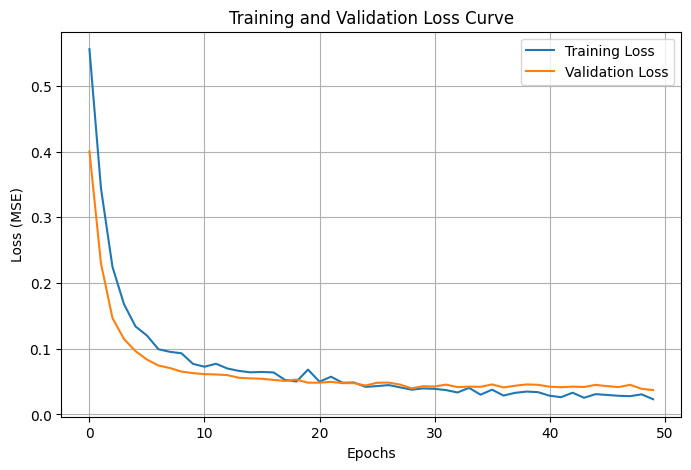

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()